# Single Backtest Runner

This notebook orchestrates a single backtest run using the `ggTrader` orchestrator api. It supports flexible configuration and interactive visualization of performance results.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import vectorbt as vbt
import matplotlib.pyplot as plt

# Auto-reload custom modules
%load_ext autoreload
%autoreload 2

# Ensure project root is in path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if project_root not in sys.path:
    sys.path.append(project_root)

from ggTrader.core.orchestrator import run_backtest_orchestrator

print("Environment initialized.")

Environment initialized.


In [2]:
# --- Configuration ---
CONSTANTS = {
    "SYMBOLS": None,
    "SYMBOLS_FILE": os.path.join(os.getcwd(), "..", "data", "top_20_USD_1095_movers.json"),
    "INTERVAL": "4h",
    "START_DATE": "2023-01-01",
    "END_DATE": "2025-12-31",
    "START_CASH": 1000,
    "PORTFOLIO_SHARE": 0.10,
    "FEES": 0.005,
    "USE_MOVERS": 0,
    "SLIPPAGE": 0.003,
    "DEFAULT_PARAMS": {
        # entry
        "sar_acceleration": 0.02,
        "use_dmp_cross": False,
        "sar_maximum": 0.2,
        "adx_threshold": 10,
        "adx_length": 14,
        # exit
        "atr_multiplier": 0.015,
        "atr_length": 10,

    }
}

print("Configuration loaded.")

Configuration loaded.


In [3]:
# --- Run Backtest ---
# Set save_results=False for pure interactive work, or True to persist to results/ folder
results = run_backtest_orchestrator(
    config=CONSTANTS, 
    params=CONSTANTS["DEFAULT_PARAMS"], 
    save_results=False,
    show_progress=True
)

pf = results["portfolio"]
stats = results["stats"]

print("\nBacktest Complete.")

Loading data...
Running backtest...


  0%|          | 0/1 [00:00<?, ?it/s]


Backtest Complete.


In [4]:
from tabulate import tabulate

# --- Visualization ---
print("Global Portfolio Stats:")
# Convert stats to a DataFrame for a cleaner table view
stats_df = pf.stats().to_frame(name="Value").reset_index()

# 2. Format only the numbers to 2 decimals (ignoring dates and durations)
def format_values(x):
    if isinstance(x, (float, np.floating)):
        return f"{x:.2f}"
    return str(x)
stats_df["Value"] = stats_df["Value"].apply(format_values)

# 3. Print with tabulate (no floatfmt needed now because we formatted them in step 2)
print(tabulate(stats_df, headers=["Metric", "Value"], tablefmt="simple", numalign="right", showindex=False))


Global Portfolio Stats:
Metric                      Value
--------------------------  -------------------------
Start                       2023-01-01 00:00:00+00:00
End                         2025-12-30 16:00:00+00:00
Period                      1094 days 20:00:00
Start Value                 1000.00
End Value                   6511.60
Total Return [%]            551.16
Benchmark Return [%]        210.30
Max Gross Exposure [%]      83.80
Total Fees Paid             7966.35
Max Drawdown [%]            25.34
Max Drawdown Duration       207 days 00:00:00
Total Trades                5187
Total Closed Trades         5173
Total Open Trades           14
Open Trade PnL              -42.53
Win Rate [%]                37.21
Best Trade [%]              479.43
Worst Trade [%]             -35.77
Avg Winning Trade [%]       8.35
Avg Losing Trade [%]        -3.38
Avg Winning Trade Duration  4 days 06:55:10.129870129
Avg Losing Trade Duration   2 days 14:04:52.610837438
Profit Factor               1.

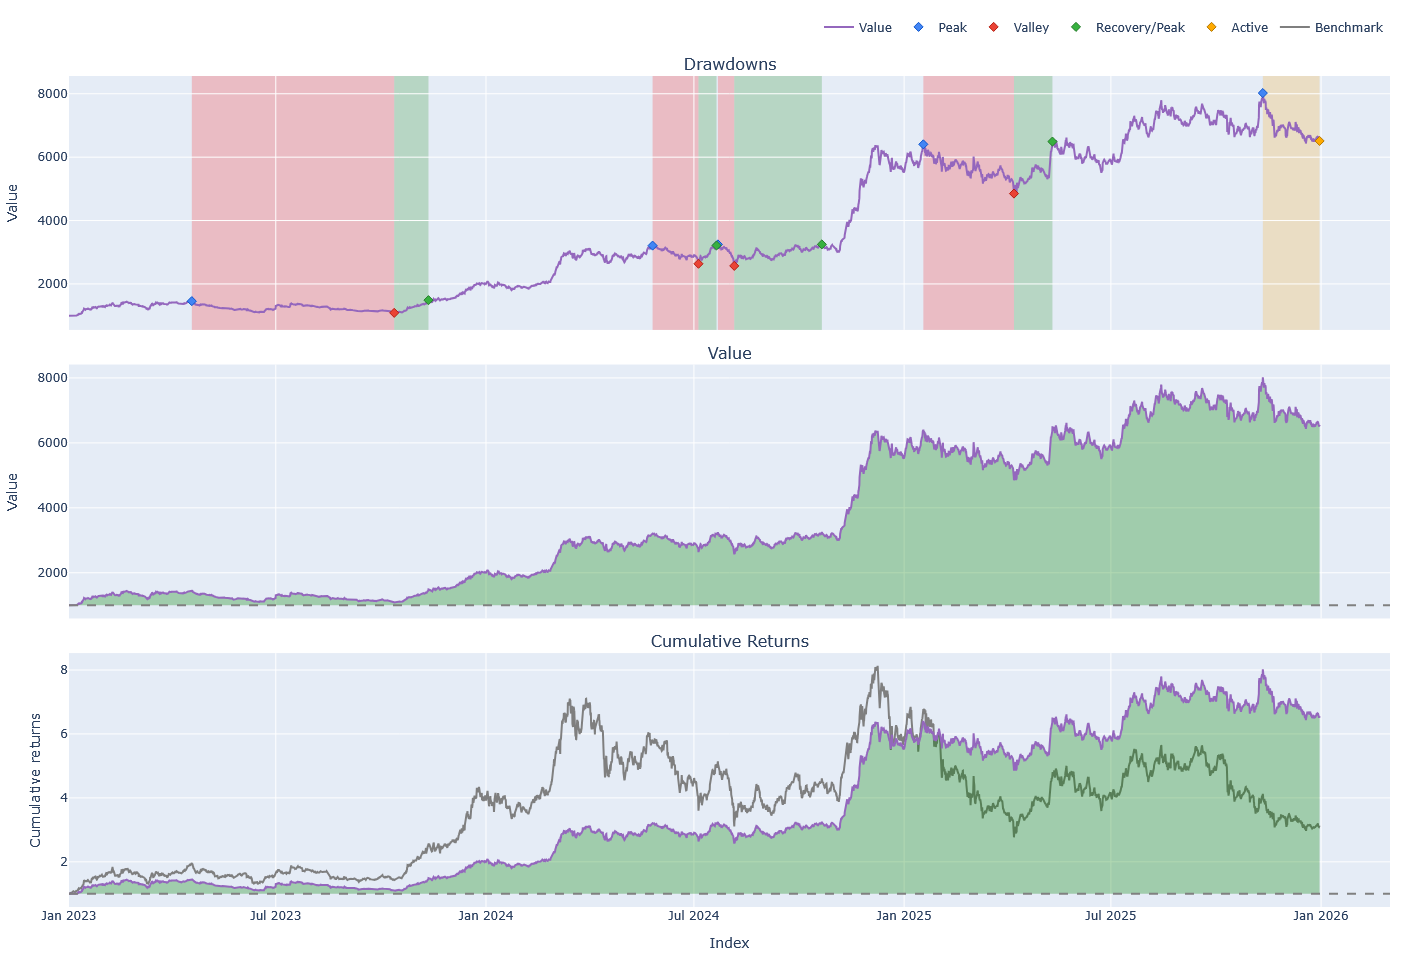

In [5]:
pf.plot(subplots=['drawdowns','value','cum_returns' ]).show()